In [22]:
import os
import json
import random
import itertools
from IPython.display import display, HTML

import numpy as np
from tqdm.auto import tqdm

import torch
import torchvision
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib import colormaps

from models import ImageClassificationModel, get_model
from data import MNISTDataset, get_dataset

# plt.rcParams["font.size"] = 24
# plt.rcParams["font.family"] = "cmr10"

In [2]:
device = "cuda:7"
model_dir = "/home/xia/claim-xai/configs/sciver/base"
model_config = json.load( open(os.path.join(model_dir, "config.json"), "r") )
model_metadata = json.load( open(os.path.join(model_dir, "masker/_metadata.json"), "r") )

In [3]:
ds_train, ds_val, ds_test, num_classes = get_dataset(
    model_config["dataset_name"], 
    data_dir = "../_datasets", 
    splits = ["train", "validation", "test"],
    **model_config["dataset_args"], 
)


model = get_model(
    model_name = model_config["model_name"],
    checkpoint_path = os.path.join(model_dir, model_metadata["best_checkpoint"]),
    **model_config["model_args"]
).eval().to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


---

In [4]:
# correct = 0

# with torch.no_grad():
#     for images, labels in tqdm(DataLoader(ds_test, batch_size=32, num_workers=2)):
#         images = images.to(device)
#         labels = labels.to(device)
        
#         inputs = model.preprocess(images)
#         logits, _ = model(inputs)

#         correct += (torch.argmax(logits, dim=1) == labels).sum()

# print(correct / len(ds_test))

pred=1 label=1


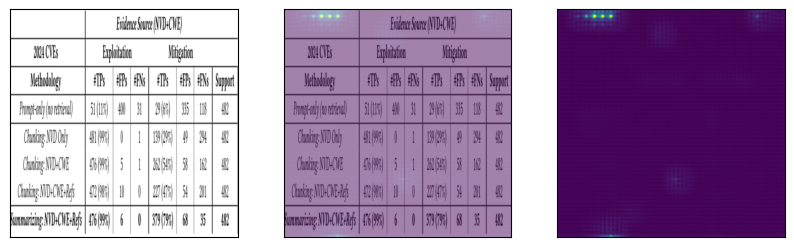

In [31]:
inputs, label = ds_test[30]

with torch.no_grad():
    prepro_inputs = model.preprocess(inputs)
    logits, text_weights, image_weights = model(*prepro_inputs)

image_plot = inputs["image"].permute(1, 2, 0).cpu()
weights_plot = image_weights[0].cpu()
weights_plot = torchvision.transforms.functional.resize(weights_plot, (image_plot.shape[0], image_plot.shape[1]), interpolation=torchvision.transforms.InterpolationMode.BILINEAR)
weights_plot = weights_plot.permute(1, 2, 0)
# weights_plot = (weights_plot - weights_plot.min()) / (weights_plot.max() - weights_plot.min())



# print(weights_plot.max(), weights_plot.min())

print(f"pred={torch.argmax(logits).item()} label={label}")



plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_plot)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(image_plot)
plt.imshow(weights_plot, alpha=0.5)
plt.xticks([]); plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(weights_plot)
plt.xticks([]); plt.yticks([])

plt.show()





tokens = prepro_inputs[0]["input_ids"][0]

text = []
scores = []
curr_word = []

for t, w in zip(tokens[1:], text_weights[0, 1:, 0].tolist()):
    tok = model.text_encoder._model.tokenizer.decode(t)
    if tok == "<pad>": break

    if (len(curr_word) != 0) and (tok[0] == ' '):
        text.append("".join([t for t, w in curr_word]).strip())
        scores.append(sum([w for t, w in curr_word]) / len(curr_word))
        curr_word = []
    curr_word.append((tok, w))
    
if len(curr_word) != 0:
    text.append("".join([t for t, w in curr_word]).strip())
    scores.append(sum([w for t, w in curr_word]) / len(curr_word))

def highlighter(word, score):
    color = colormaps["OrRd"](round((score) * 255))
    color = [round(c*255) for c in color]
    return f"<span style='color: {'whitw' if score > 0.75 else 'black'}; background-color: rgb({color[0]} {color[1]} {color[2]})'>{word}</span>"

display(HTML(
    ' '.join([highlighter(t, s) for t, s in zip(text, scores)])
))





# plt.hist(weights_plot.flatten())
# plt.yscale("log")
# plt.show()